# Análise Exploratória de Dados — Bank Marketing

## Objetivo

Este notebook realiza a Análise Exploratória de Dados (EDA) da base Bank Marketing utilizada no Datathon da Pós-Tech em Machine Learning Engineering da FIAP.

A base contém informações relacionadas a campanhas de marketing de uma instituição bancária, tendo como variável alvo `y`, que indica se o cliente realizou ou não a assinatura de um depósito a prazo.

Nesta etapa serão analisados:

- estrutura da base;
- tipos das variáveis;
- valores ausentes ou desconhecidos;
- registros duplicados;
- estatísticas descritivas;
- distribuição das variáveis;
- distribuição da variável alvo;
- possíveis relações entre as características dos clientes e a conversão.

As decisões definitivas de preparação dos dados serão realizadas posteriormente na etapa de pré-processamento.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank-additional-full.csv"

df = pd.read_csv(DATA_PATH, sep=";")

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de registros: 41188
Quantidade de colunas: 21


### Dimensão do dataset

A base possui 41.188 registros e 21 colunas, sendo 20 variáveis de entrada e uma variável alvo (`y`).

In [6]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [8]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [9]:
categorical_columns = df.select_dtypes(include="object").columns

unknown_counts = pd.DataFrame({
    "unknown_count": [
        (df[column] == "unknown").sum()
        for column in categorical_columns
    ]
}, index=categorical_columns)

unknown_counts["unknown_percentage"] = (
    unknown_counts["unknown_count"] / len(df) * 100
)

unknown_counts = unknown_counts[
    unknown_counts["unknown_count"] > 0
].sort_values("unknown_count", ascending=False)

unknown_counts

,unknown_count,unknown_percentage
default,8597,20.872584
education,1731,4.202680
housing,990,2.403613
loan,990,2.403613
job,330,0.801204
marital,80,0.194231


### Valores ausentes e desconhecidos

Não foram encontrados valores nulos (`NaN`) na base. Entretanto, algumas variáveis categóricas utilizam a categoria `unknown` para representar informações desconhecidas.

A variável `default` apresenta a maior ocorrência dessa categoria, em aproximadamente 20,9% dos registros. Outras variáveis, como `education`, `housing`, `loan`, `job` e `marital`, também apresentam valores desconhecidos em menor proporção.

O tratamento dessas categorias será definido posteriormente durante a etapa de preparação dos dados.

In [10]:
duplicated_count = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicated_count}")

Quantidade de registros duplicados: 12


### Registros duplicados

Foram identificados 12 registros completamente duplicados na base.

A remoção desses registros será realizada posteriormente durante a etapa de preparação dos dados.

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [12]:
target_counts = df["y"].value_counts()

target_counts

y
no     36548
yes     4640
Name: count, dtype: int64

In [13]:
target_percentage = df["y"].value_counts(normalize=True) * 100

target_percentage

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

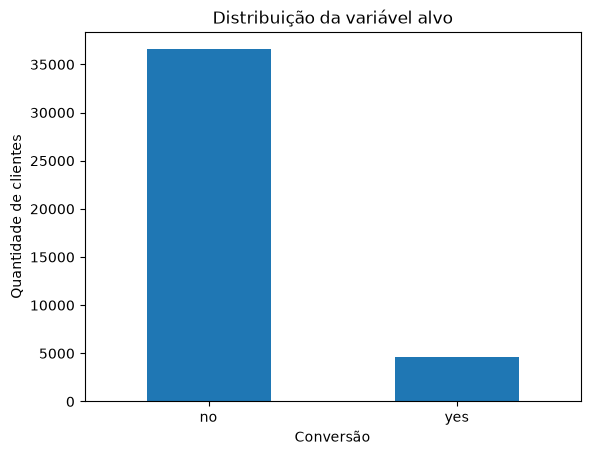

In [14]:
df["y"].value_counts().plot(kind="bar")

plt.title("Distribuição da variável alvo")
plt.xlabel("Conversão")
plt.ylabel("Quantidade de clientes")
plt.xticks(rotation=0)
plt.show()

### Distribuição da variável alvo

A variável alvo apresenta um desbalanceamento significativo.

Aproximadamente 88,7% dos clientes não realizaram a assinatura do depósito a prazo, enquanto cerca de 11,3% apresentaram conversão.

Esse comportamento é esperado em campanhas de marketing, nas quais a quantidade de clientes que aceitam uma oferta geralmente é inferior à quantidade de clientes que a rejeitam.

Esse desbalanceamento deverá ser considerado posteriormente durante a avaliação da solução.

### Possível vazamento de informação — `duration`

A variável `duration` representa a duração da última chamada realizada com o cliente.

Essa informação apresenta risco de vazamento de dados, pois a duração completa da chamada somente é conhecida após o contato ter ocorrido. Dessa forma, ela não estaria disponível no momento em que uma decisão de oferta precisasse ser realizada.

A coluna será mantida durante a análise exploratória para permitir sua investigação, mas deverá ser removida durante a etapa de preparação dos dados antes da construção da solução.

In [15]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_columns

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

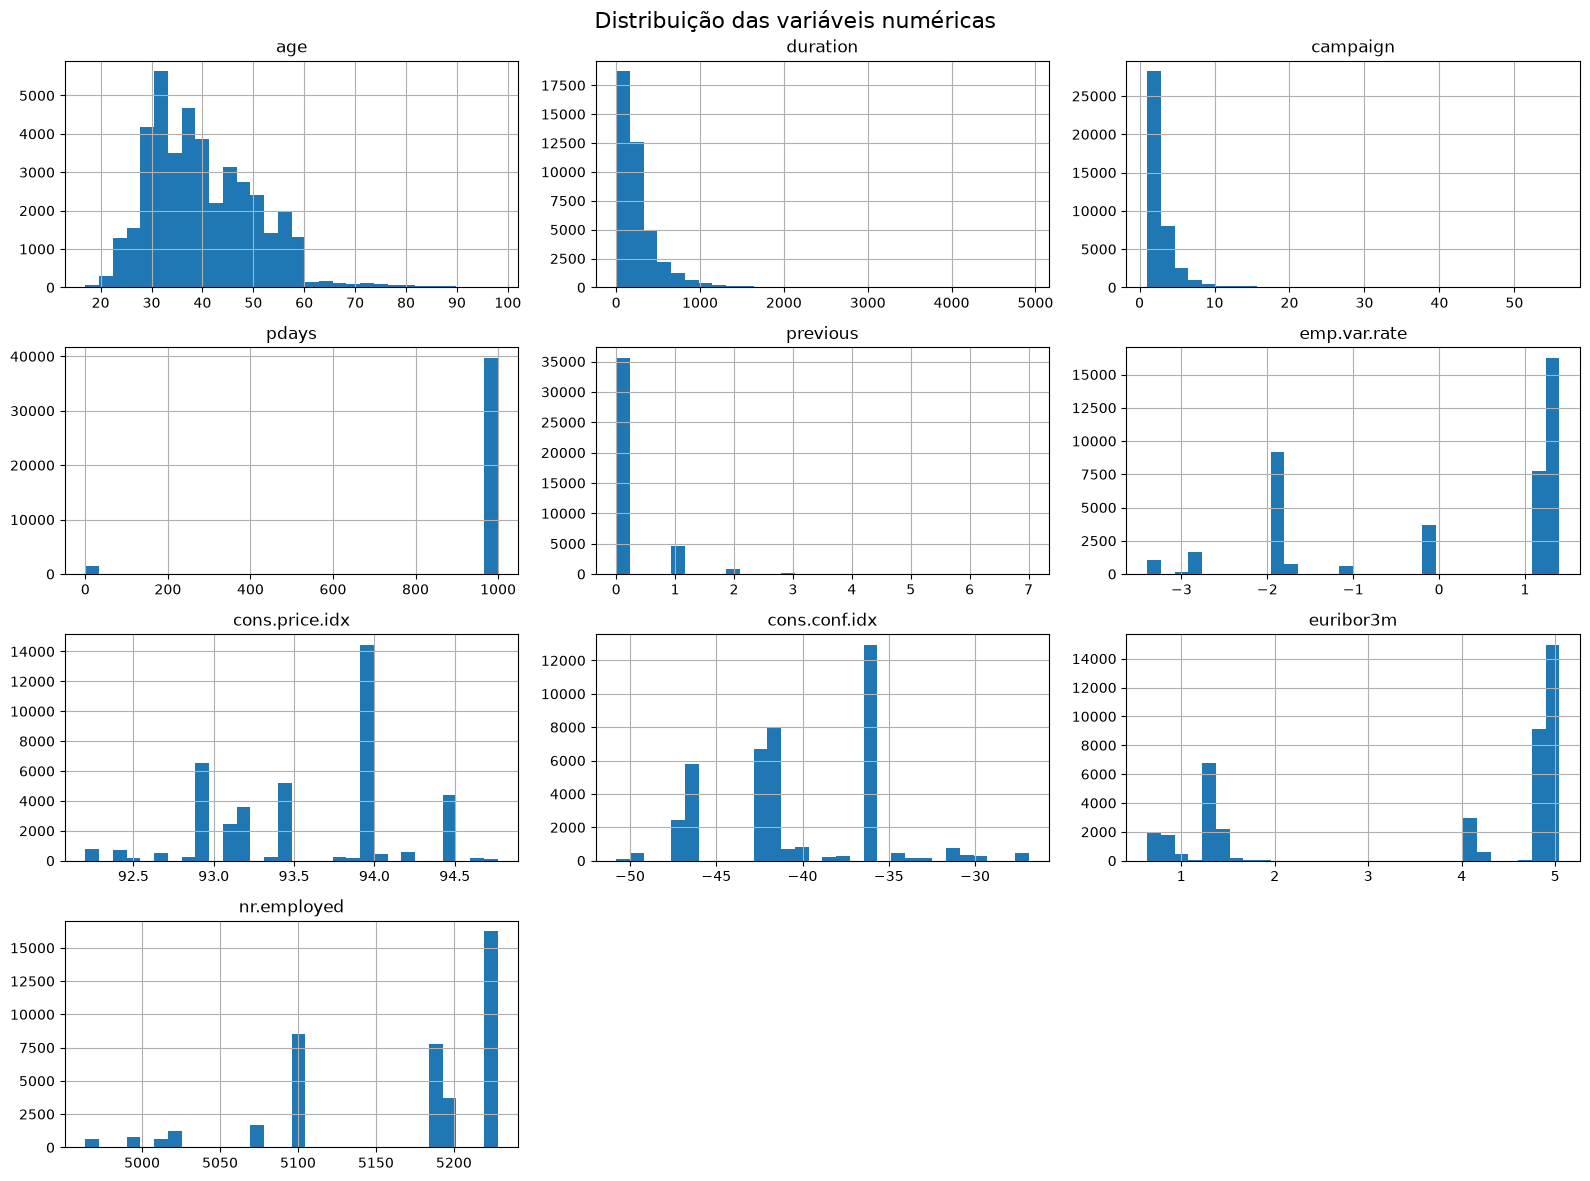

In [16]:
df[numeric_columns].hist(
    bins=30,
    figsize=(16, 12)
)

plt.suptitle("Distribuição das variáveis numéricas", fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
df["pdays"].value_counts().head(15)

pdays
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
Name: count, dtype: int64

In [18]:
pdays_not_contacted = (df["pdays"] == 999).sum()

print(f"Clientes sem contato anterior: {pdays_not_contacted}")
print(f"Percentual: {pdays_not_contacted / len(df) * 100:.2f}%")

Clientes sem contato anterior: 39673
Percentual: 96.32%


### Observação sobre a variável `pdays`

A variável `pdays` representa a quantidade de dias desde o último contato realizado com o cliente em uma campanha anterior.

O valor `999` possui um significado especial na base: indica que o cliente não havia sido contatado anteriormente.

Aproximadamente 96,3% dos registros apresentam `pdays = 999`, mostrando que a grande maioria dos clientes não possuía contato registrado em campanhas anteriores.

Esse valor não deve ser interpretado diretamente como 999 dias e seu tratamento será avaliado posteriormente durante a etapa de preparação dos dados.

In [19]:
df["campaign"].value_counts().sort_index().head(15)

campaign
1     17642
2     10570
3      5341
4      2651
5      1599
6       979
7       629
8       400
9       283
10      225
11      177
12      125
13       92
14       69
15       51
Name: count, dtype: int64

In [20]:
df["campaign"].describe()

count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

### Distribuição do número de contatos

A variável `campaign` apresenta distribuição assimétrica, com maior concentração em poucos contatos por cliente e uma quantidade reduzida de registros com números elevados de contatos.

A existência desses valores será considerada posteriormente durante o pré-processamento, sem realizar alterações nesta etapa exploratória.

In [21]:
df["previous"].value_counts().sort_index()

previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64

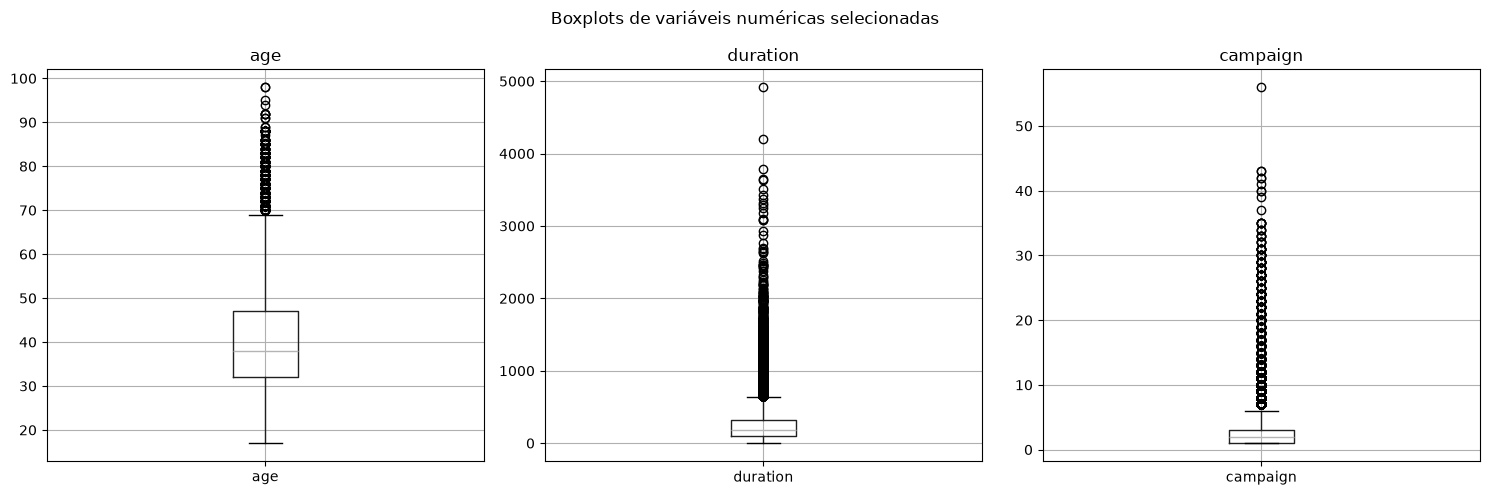

In [22]:
columns_boxplot = ["age", "duration", "campaign"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, column in zip(axes, columns_boxplot):
    df.boxplot(column=column, ax=ax)
    ax.set_title(column)

plt.suptitle("Boxplots de variáveis numéricas selecionadas")
plt.tight_layout()
plt.show()

### Principais observações das variáveis numéricas

A análise das distribuições numéricas permitiu identificar alguns comportamentos relevantes:

- a variável `age` apresenta maior concentração em clientes adultos, com alguns registros em faixas etárias mais elevadas;
- `duration` possui forte assimetria à direita e apresenta chamadas com duração significativamente superior à maioria dos registros;
- `campaign` também apresenta distribuição assimétrica, indicando que a maioria dos clientes recebeu poucos contatos durante a campanha;
- a maior parte dos registros possui `previous = 0`, indicando ausência de contatos em campanhas anteriores;
- em `pdays`, o valor `999` representa clientes que não haviam sido contatados anteriormente, correspondendo à grande maioria da base;
- as variáveis econômicas apresentam distribuições específicas associadas ao período em que as campanhas foram realizadas.

Os possíveis tratamentos dessas características serão avaliados posteriormente durante a etapa de preparação dos dados.

In [23]:
categorical_columns = [
    column
    for column in df.select_dtypes(include="object").columns
    if column != "y"
]

categorical_columns

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

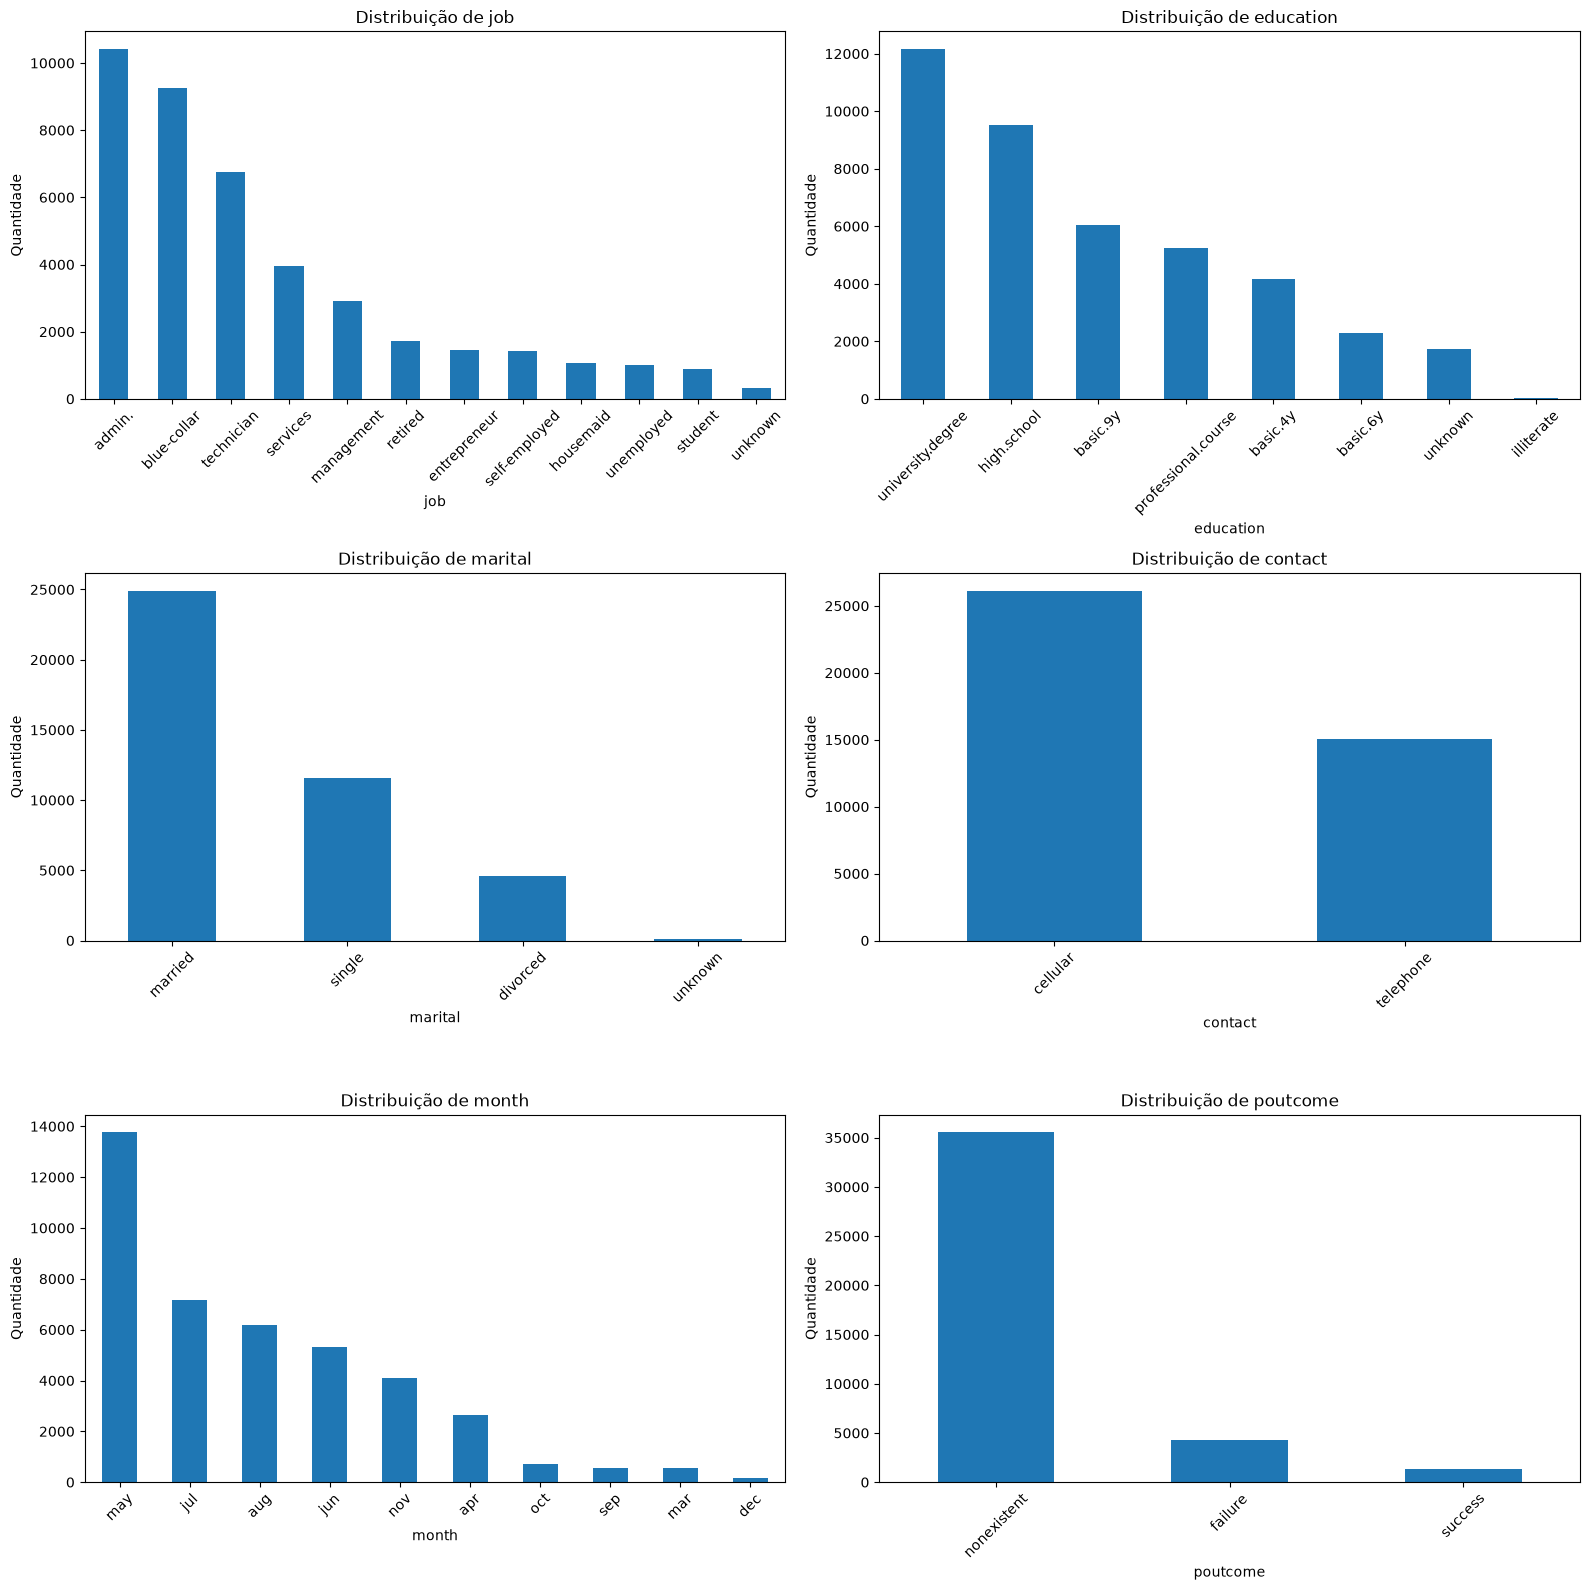

In [24]:
categorical_plot_columns = [
    "job",
    "education",
    "marital",
    "contact",
    "month",
    "poutcome"
]

fig, axes = plt.subplots(3, 2, figsize=(16, 16))

for ax, column in zip(axes.flatten(), categorical_plot_columns):
    df[column].value_counts().plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"Distribuição de {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Quantidade")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Principais observações das variáveis categóricas

A análise das variáveis categóricas mostra que:

- `job` possui maior concentração nas categorias `admin.`, `blue-collar` e `technician`;
- `education` apresenta maior presença de clientes com `university.degree` e `high.school`;
- a maior parte dos clientes possui estado civil `married`;
- o contato por `cellular` é mais frequente do que por `telephone`;
- a quantidade de contatos varia significativamente entre os meses da campanha;
- em `poutcome`, a maior parte dos registros está classificada como `nonexistent`, indicando ausência de resultado de uma campanha anterior.

Algumas categorias possuem baixa quantidade de registros e, portanto, eventuais taxas de conversão elevadas nesses grupos devem ser interpretadas com cautela.

In [25]:
def conversion_rate_by_category(dataframe, column):
    conversion_rate = (
        pd.crosstab(
            dataframe[column],
            dataframe["y"],
            normalize="index"
        )["yes"] * 100
    )

    return conversion_rate.sort_values(ascending=False)

In [26]:
conversion_rate_by_category(df, "job")

job
student          31.428571
retired          25.232558
unemployed       14.201183
admin.           12.972558
management       11.217510
unknown          11.212121
technician       10.826042
self-employed    10.485574
housemaid        10.000000
entrepreneur      8.516484
services          8.138070
blue-collar       6.894316
Name: yes, dtype: float64

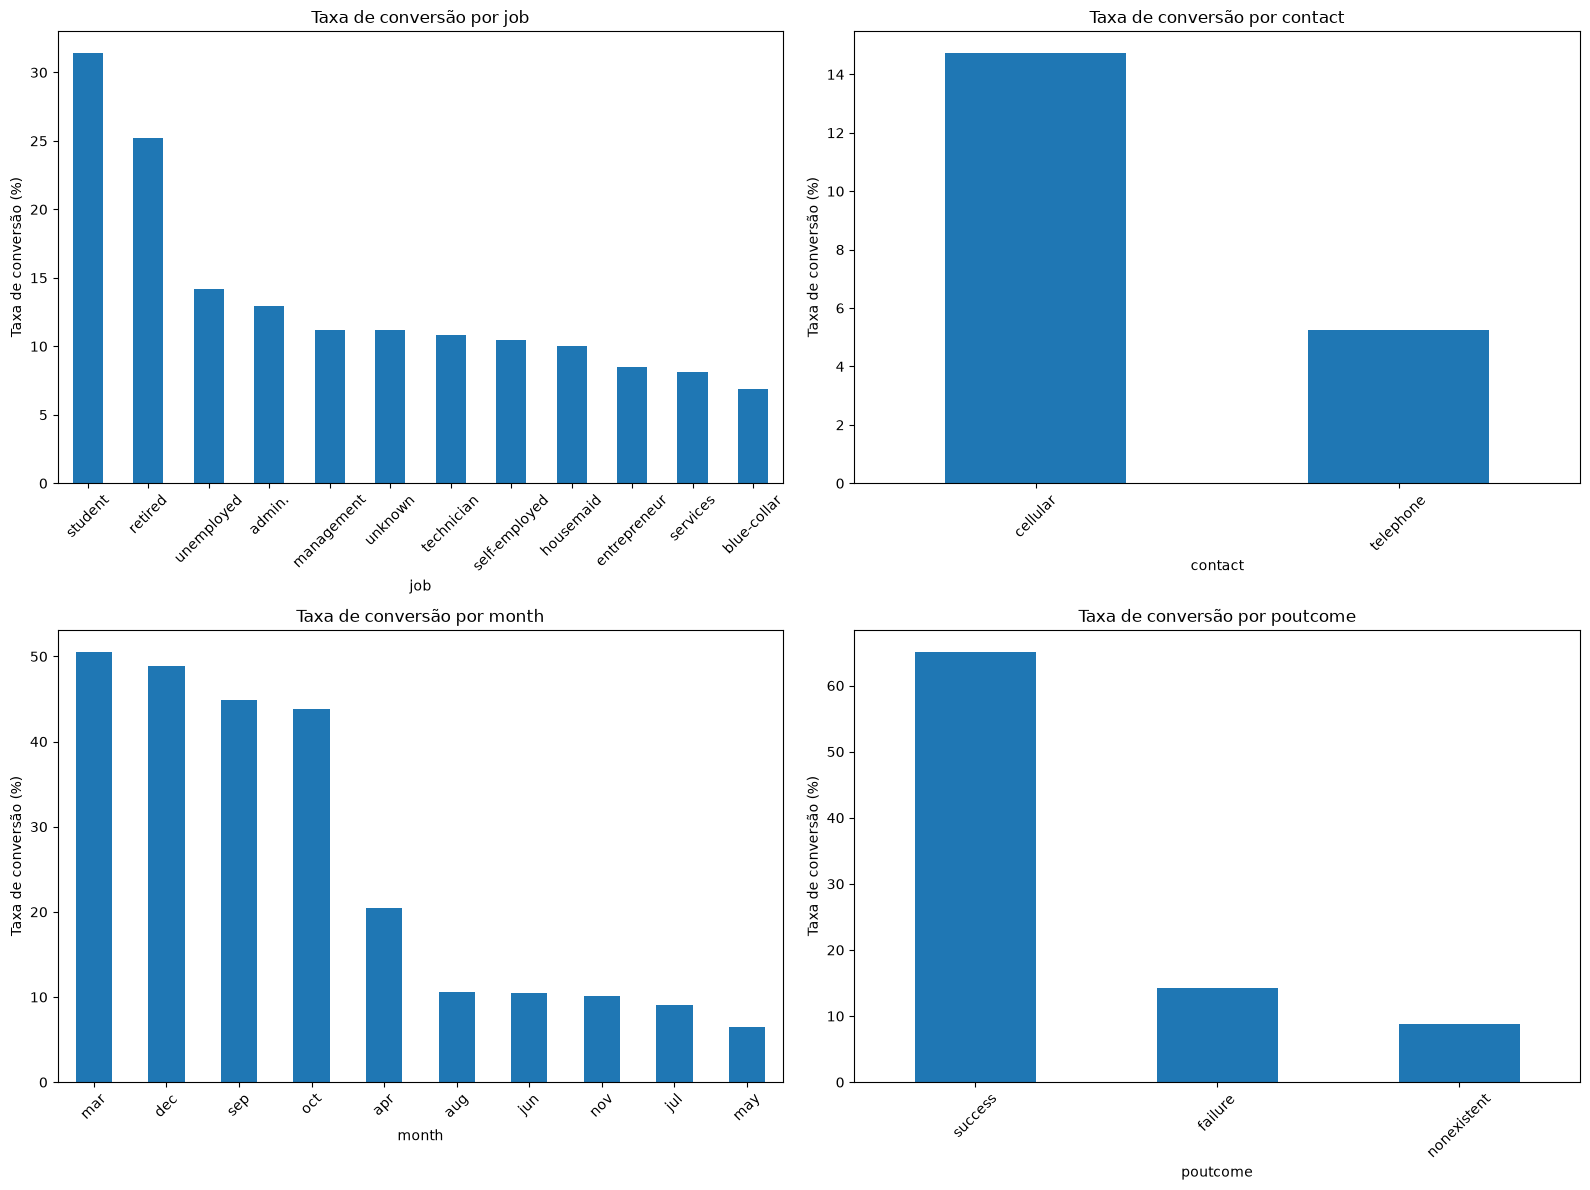

In [27]:
conversion_columns = [
    "job",
    "contact",
    "month",
    "poutcome"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, column in zip(axes.flatten(), conversion_columns):
    conversion_rate = conversion_rate_by_category(df, column)

    conversion_rate.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"Taxa de conversão por {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Taxa de conversão (%)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Relação entre variáveis categóricas e conversão

Foram observadas diferenças relevantes nas taxas de conversão entre algumas categorias.

O tipo de contato apresentou associação com o resultado da campanha, com contatos realizados por celular apresentando taxa de conversão superior aos realizados por telefone.

A variável `poutcome` apresentou uma das diferenças mais expressivas: clientes que tiveram sucesso em campanhas anteriores apresentaram uma taxa de conversão significativamente superior aos clientes sem histórico de campanha ou com campanhas anteriores sem sucesso.

Também foram observadas diferenças entre profissões e entre os meses de realização da campanha.

Esses resultados representam associações presentes nos dados e não devem ser interpretados como relações causais. Além disso, categorias com menor quantidade de registros podem apresentar taxas percentuais mais instáveis.

In [28]:
numeric_target_summary = (
    df.groupby("y")[numeric_columns]
    .mean()
    .T
)

numeric_target_summary

y,no,yes
age,39.911185,40.913147
duration,220.844807,553.191164
campaign,2.633085,2.051724
pdays,984.113878,792.035560
previous,0.132374,0.492672
emp.var.rate,0.248875,-1.233448
cons.price.idx,93.603757,93.354386
cons.conf.idx,-40.593097,-39.789784
euribor3m,3.811491,2.123135
nr.employed,5176.166600,5095.115991


### Relação entre variáveis numéricas e conversão

A comparação das variáveis numéricas entre clientes que converteram e não converteram revelou algumas diferenças relevantes.

A variável `duration` apresenta uma diferença expressiva entre os grupos. Entretanto, como a duração total da ligação somente é conhecida após o contato, sua utilização representaria vazamento de informação e a variável será removida durante o pré-processamento.

Clientes que converteram também apresentam, em média, maior número de contatos em campanhas anteriores (`previous`) e diferenças em algumas variáveis macroeconômicas, como `emp.var.rate`, `euribor3m` e `nr.employed`.

Essas diferenças serão consideradas durante a preparação dos dados e construção da solução, sem assumir relações causais a partir da análise exploratória.

# Conclusões da Análise Exploratória

A análise exploratória da base Bank Marketing permitiu compreender a estrutura dos dados e identificar características importantes para as próximas etapas do projeto.

Os principais pontos encontrados foram:

- a base possui 41.188 registros e 21 colunas, incluindo a variável alvo `y`;
- não foram encontrados valores nulos no formato `NaN`, porém algumas variáveis categóricas possuem valores `unknown`;
- a variável `default` apresenta a maior proporção de valores desconhecidos;
- foram identificados 12 registros duplicados;
- a variável alvo apresenta desbalanceamento significativo, com aproximadamente 11,3% dos registros representando conversões;
- algumas variáveis numéricas apresentam distribuições assimétricas e valores extremos;
- o valor `999` em `pdays` representa clientes que nunca haviam sido contatados anteriormente e não deve ser interpretado literalmente como quantidade de dias;
- a variável `duration` apresenta vazamento de informação e deverá ser removida antes da construção da solução;
- foram observadas diferenças nas taxas de conversão de acordo com características como tipo de contato, histórico de campanhas anteriores, profissão e período da campanha;
- variáveis relacionadas ao histórico do cliente e ao contexto econômico também apresentam diferenças entre clientes que converteram e não converteram.

A análise realizada nesta etapa é exploratória e não estabelece relações causais entre as variáveis e a conversão.

Na próxima etapa serão realizadas as decisões de preparação da base, incluindo tratamento dos registros duplicados, análise das categorias desconhecidas, tratamento da variável `pdays`, remoção de `duration`, transformação das variáveis categóricas e definição das features utilizadas pela solução.